## Time Series Exploration & Preprocessing

**Imports and paths**

In [1]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

DATA_ROOT = Path("../dataset/data")
CONSUMPTION = DATA_ROOT / "consumption_data"
SIX_HOUR_FILES = sorted(glob.glob(str(CONSUMPTION / "smart_meter" / "6hour_interval" / "smart_6hour_*.csv")))

print(f"6-hour interval files: {len(SIX_HOUR_FILES)}")


6-hour interval files: 5


**Load all 5 files, pruned to just the columns we need**

In [2]:
COLUMNS_NEEDED = ["household_ID", "DATE", "TIME", "TOTAL_IMPORT (kWh)"]

frames = []
for f in SIX_HOUR_FILES:
    df = pd.read_csv(f, usecols=COLUMNS_NEEDED, low_memory=False)
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)
print("Combined shape:", raw.shape)
raw.head()


Combined shape: (4441793, 4)


,household_ID,DATE,TIME,TOTAL_IMPORT (kWh)
0,ID5111,2023-01-01,00:40:14,870.311
1,ID2772,2023-01-01,18:53:17,1092.5241
2,ID3150,2023-01-01,18:55:21,1286.771
3,ID1674,2023-01-01,18:58:02,516.81
4,ID5100,2023-01-01,18:58:24,14655.07


**Build timestamp, coerce numeric defensively, sort**

In [3]:
raw["TOTAL_IMPORT (kWh)"] = pd.to_numeric(raw["TOTAL_IMPORT (kWh)"], errors="coerce")
# Remove milliseconds
raw['TIME'] = raw['TIME'].str[:8]
raw["timestamp"] = pd.to_datetime(raw["DATE"] + " " + raw["TIME"], format="ISO8601")

n_bad_import = raw["TOTAL_IMPORT (kWh)"].isna().sum()
print(f"Rows with non-numeric/missing TOTAL_IMPORT: {n_bad_import} ({n_bad_import / len(raw) * 100:.4f}%)")

raw = raw.sort_values(["household_ID", "timestamp"]).reset_index(drop=True)
raw[["household_ID", "timestamp", "TOTAL_IMPORT (kWh)"]].head()


Rows with non-numeric/missing TOTAL_IMPORT: 15 (0.0003%)


,household_ID,timestamp,TOTAL_IMPORT (kWh)
0,ID0013,2023-02-01 02:29:52,402.916
1,ID0013,2023-02-01 06:21:23,403.764
2,ID0013,2023-02-02 01:20:09,407.743
3,ID0013,2023-02-02 06:26:00,408.860
4,ID0013,2023-02-03 01:25:18,413.213


**Check for duplicate (household, timestamp) reads**

In [4]:
dupes = raw.duplicated(subset=["household_ID", "timestamp"], keep=False)
print(f"Duplicate (household_ID, timestamp) rows: {dupes.sum()} ({dupes.sum() / len(raw) * 100:.4f}%)")

raw[dupes].sort_values(["household_ID", "timestamp"]).head(10)


Duplicate (household_ID, timestamp) rows: 0 (0.0000%)


,household_ID,DATE,TIME,TOTAL_IMPORT (kWh),timestamp


**Difference the cumulative counter per household**

In [5]:
raw["interval_kwh"] = raw.groupby("household_ID")["TOTAL_IMPORT (kWh)"].diff()
print(raw["interval_kwh"].describe())

n_negative = (raw["interval_kwh"] < 0).sum()
n_total = raw["interval_kwh"].notna().sum()
print(f"\nNegative diffs (counter resets) across full dataset: {n_negative} / {n_total} ({n_negative / n_total * 100:.4f}%)")


count    4.438813e+06
mean     2.681358e+00
std      4.740704e+03
min     -2.326078e+05
25%      3.080000e-01
50%      1.025000e+00
75%      2.438900e+00
max      2.326124e+05
Name: interval_kwh, dtype: float64

Negative diffs (counter resets) across full dataset: 19418 / 4438813 (0.4375%)


**Inspect the most extreme diffs**

In [6]:
extreme = raw.reindex(raw["interval_kwh"].abs().sort_values(ascending=False).index).head(20)
extreme[["household_ID", "timestamp", "TOTAL_IMPORT (kWh)", "interval_kwh"]]


,household_ID,timestamp,TOTAL_IMPORT (kWh),interval_kwh
3398754,ID4896,2024-10-31 01:16:16,232626.8111,232612.4181
3398752,ID4896,2024-10-30 01:17:56,232622.1470,232607.7690
3398753,ID4896,2024-10-31 01:13:20,14.3930,-232607.7540
3398750,ID4896,2024-10-29 01:19:22,232617.3081,232602.9461
3398751,ID4896,2024-10-30 01:17:39,14.3780,-232602.9301
3398748,ID4896,2024-10-28 01:18:47,232613.3700,232599.0200
3398749,ID4896,2024-10-29 01:16:40,14.3620,-232599.0080
3398746,ID4896,2024-10-27 04:39:21,14.3360,-232595.1280
3398744,ID4896,2024-10-26 01:19:20,232605.4480,232591.1300
3398742,ID4896,2024-10-25 01:37:13,232601.0790,232586.7750


**Quantify how widespread the extreme-value problem is**

In [7]:
# Distribution of positive diffs only (resets are handled separately)
positive_diffs = raw.loc[raw["interval_kwh"] > 0, "interval_kwh"]
print("Percentiles of positive interval_kwh:")
print(positive_diffs.quantile([0.5, 0.9, 0.99, 0.999, 0.9999, 1.0]))

# How many rows/households have an implausibly large jump (>100 kWh in a 6-hour interval)?
implausible = raw[raw["interval_kwh"].abs() > 100]
print(f"\nRows with |interval_kwh| > 100: {len(implausible)}")
implausible_householders = implausible['household_ID'].unique().tolist()
print(f"Distinct households involved: {len(implausible_householders)}")
print(f"Rows contributed by these households: {raw['household_ID'].isin(implausible_householders).sum()} ({raw['household_ID'].isin(implausible_householders).sum() / len(raw) * 100:.2f}%)")
implausible["household_ID"].value_counts().head(10)


Percentiles of positive interval_kwh:
0.5000         1.176100
0.9000         5.650000
0.9900        44.705530
0.9990     23097.267875
0.9999    197764.641715
1.0000    232612.418100
Name: interval_kwh, dtype: float64

Rows with |interval_kwh| > 100: 45220
Distinct households involved: 607
Rows contributed by these households: 907586 (20.43%)


household_ID
ID4695    2699
ID4896    2510
ID5483    2248
ID5569    2221
ID2747    1901
ID0551    1723
ID4342    1719
ID1751    1671
ID0844    1625
ID5543    1605
Name: count, dtype: int64

In [8]:
# inspect the #1 offender, ID4695
id4695 = raw[raw["household_ID"] == "ID4695"].sort_values("timestamp")
print(f"Total readings for ID4695: {len(id4695)}")
print(f"Readings with |interval_kwh| > 100: {(id4695['interval_kwh'].abs() > 100).sum()}")

id4695[["timestamp", "TOTAL_IMPORT (kWh)", "interval_kwh"]].head(15)

Total readings for ID4695: 3375
Readings with |interval_kwh| > 100: 2699


,timestamp,TOTAL_IMPORT (kWh),interval_kwh
3084313,2023-01-01 01:23:12,863.5280,NaN
3084314,2023-01-01 01:35:44,3.8950,-859.6330
3084315,2023-01-01 05:39:28,863.5280,859.6330
3084316,2023-01-01 06:40:10,3.8950,-859.6330
3084317,2023-01-01 19:25:35,863.5280,859.6330
3084318,2023-01-01 19:30:00,3.9011,-859.6269
3084319,2023-01-02 01:35:29,863.5280,859.6269
3084320,2023-01-02 01:39:51,3.9011,-859.6269
3084321,2023-01-02 06:21:41,863.5280,859.6269
3084322,2023-01-02 06:39:05,3.9011,-859.6269


**Use reading-count as a clean, principled detector for this contamination pattern**

In [9]:
MAX_POSSIBLE_READINGS = 731 * 4  # full 2023-01-01 -> 2024-12-31 span, 4 readings/day

reading_counts = raw.groupby("household_ID").size()
over_max = reading_counts[reading_counts > MAX_POSSIBLE_READINGS]

print(f"Households exceeding the theoretical max ({MAX_POSSIBLE_READINGS} readings): {len(over_max)}")
print(f"Rows contributed by these households: {raw['household_ID'].isin(over_max.index).sum()} ({raw['household_ID'].isin(over_max.index).sum() / len(raw) * 100:.2f}%)")
over_max.sort_values(ascending=False).head(10)


Households exceeding the theoretical max (2924 readings): 5
Rows contributed by these households: 15633 (0.35%)


household_ID
ID4695    3375
ID4896    3172
ID5308    3153
ID5483    2979
ID5569    2954
dtype: int64

**Drop the 5 structural households,  then cap using the dataset's own 99th percentile**

In [10]:
STRUCTURAL_BAD_HOUSEHOLDS = over_max.index.tolist()
clean = raw[~raw["household_ID"].isin(STRUCTURAL_BAD_HOUSEHOLDS)].copy()
print(f"Rows after dropping 5 households: {len(clean)} (was {len(raw)})")

Rows after dropping 5 households: 4426160 (was 4441793)


In [11]:
clean["interval_kwh"] = clean.groupby("household_ID")["TOTAL_IMPORT (kWh)"].diff()
# Find a reasonable maximum consumption
CAP_KWH = clean.loc[clean["interval_kwh"] > 0, "interval_kwh"].quantile(0.99)
print(f"Data-driven cap (99th percentile of positive diffs): {CAP_KWH:.3f} kWh")

Data-driven cap (99th percentile of positive diffs): 37.480 kWh


In [12]:
# Identify bad readings
bad_reading = (clean["interval_kwh"] < 0) | (clean["interval_kwh"] > CAP_KWH)
n_bad = bad_reading.sum()
print(f"Row-level bad readings (negative or > cap): {n_bad} ({n_bad / clean['interval_kwh'].notna().sum() * 100:.3f}%)")

Row-level bad readings (negative or > cap): 53877 (1.218%)


Instead of deleting entire rows, the suspicious interval values are marked as missing (NaN). This preserves the rest of the row (timestamp, household ID, etc.), allowing to later decide whether to interpolate, ignore, or otherwise handle the missing consumption values.

In [13]:
clean.loc[bad_reading, "interval_kwh"] = np.nan
clean["interval_kwh"].describe()

count    4.369308e+06
mean     2.105220e+00
std      3.529838e+00
min      0.000000e+00
25%      3.110000e-01
50%      1.015000e+00
75%      2.373000e+00
max      3.748000e+01
Name: interval_kwh, dtype: float64

**Aggregate to daily national total consumption**

In [14]:
clean["date"] = pd.to_datetime(clean["DATE"])

daily_national = clean.groupby("date")["interval_kwh"].sum(min_count=1)
daily_national = daily_national.to_frame().reset_index()
print("Daily series shape:", daily_national.shape)
print("Date range:", daily_national.index.min(), "->", daily_national.index.max())
print("\nAny NaN days (zero valid readings that day)?", daily_national.isna().sum())
daily_national.describe()


Daily series shape: (726, 2)
Date range: 0 -> 725

Any NaN days (zero valid readings that day)? date            0
interval_kwh    1
dtype: int64


,date,interval_kwh
count,726,725.000000
mean,2023-12-31 03:24:17.851239680,12687.388411
min,2023-01-01 00:00:00,0.000000
25%,2023-07-01 06:00:00,12225.167900
50%,2023-12-29 12:00:00,13812.211900
75%,2024-07-02 18:00:00,14945.075800
max,2024-12-31 00:00:00,32495.262400
std,NaN,4327.261135


In [15]:
print(type(daily_national))
daily_national.head()

<class 'pandas.core.frame.DataFrame'>


,date,interval_kwh
0,2023-01-01,4148.1189
1,2023-01-02,5865.8369
2,2023-01-03,5582.9238
3,2023-01-04,5704.3896
4,2023-01-05,5746.2778


In [16]:
expected_days = pd.date_range("2023-01-01", "2024-12-31", freq="D")
actual_days = pd.to_datetime(clean["date"].unique())
missing_days = expected_days.difference(actual_days)
print(f"Missing calendar days: {len(missing_days)}")
missing_days

Missing calendar days: 5


DatetimeIndex(['2024-04-11', '2024-05-09', '2024-05-10', '2024-05-11',
               '2024-05-12'],
              dtype='datetime64[ns]', freq=None)

In [17]:
missing_records = clean[clean['DATE'].isin(missing_days)]
display(missing_records)

,household_ID,DATE,TIME,TOTAL_IMPORT (kWh),timestamp,interval_kwh,date


**Rebuild the daily series against the full calendar**

In [18]:
daily_national = clean.groupby("date")["interval_kwh"].sum(min_count=1)

full_calendar = pd.date_range("2023-01-01", "2024-12-31", freq="D")
daily_national = daily_national.reindex(full_calendar)
daily_national.index.name = "date"
daily_national = daily_national.to_frame().reset_index()

print(type(daily_national))
print("Shape:", daily_national.shape)
print("Missing values:", daily_national.isna().sum())
daily_national.describe()


<class 'pandas.core.frame.DataFrame'>
Shape: (731, 2)
Missing values: date            0
interval_kwh    6
dtype: int64


,date,interval_kwh
count,731,725.000000
mean,2024-01-01 00:00:00,12687.388411
min,2023-01-01 00:00:00,0.000000
25%,2023-07-02 12:00:00,12225.167900
50%,2024-01-01 00:00:00,13812.211900
75%,2024-07-01 12:00:00,14945.075800
max,2024-12-31 00:00:00,32495.262400
std,NaN,4327.261135


In [19]:
daily_national[daily_national["interval_kwh"].isna()]

,date,interval_kwh
466,2024-04-11,NaN
494,2024-05-09,NaN
495,2024-05-10,NaN
496,2024-05-11,NaN
497,2024-05-12,NaN
500,2024-05-15,NaN


In [20]:
day_rows = clean[clean["date"] == "2024-05-15"]
print("Rows on 2024-05-15:", len(day_rows))
print("\ninterval_kwh stats (including excluded/NaN):")
print(day_rows["interval_kwh"].describe())
print("\nHow many are NaN (excluded)?", day_rows["interval_kwh"].isna().sum())

# Look at the raw (uncapped) diff before exclusion, to see the true jump size
day_rows_raw = raw[(pd.to_datetime(raw["DATE"]) == "2024-05-15") & (~raw["household_ID"].isin(STRUCTURAL_BAD_HOUSEHOLDS))]
day_rows_raw["interval_kwh"].describe()


Rows on 2024-05-15: 1

interval_kwh stats (including excluded/NaN):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: interval_kwh, dtype: float64

How many are NaN (excluded)? 1


count       1.000
mean     1097.708
std           NaN
min      1097.708
25%      1097.708
50%      1097.708
75%      1097.708
max      1097.708
Name: interval_kwh, dtype: float64

**Interpolate the 6 gaps**

In [21]:
daily_national = daily_national.set_index("date")["interval_kwh"]
daily_national_filled = daily_national.interpolate(method="time")

print("Remaining NaNs after interpolation:", daily_national_filled.isna().sum())
daily_national_filled.describe()


Remaining NaNs after interpolation: 0


count      731.000000
mean     12608.341022
std       4420.478208
min          0.000000
25%      12212.862050
50%      13793.954400
75%      14941.308850
max      32495.262400
Name: interval_kwh, dtype: float64

In [22]:
daily_national_filled.sort_values().head(5)

date
2024-05-16      0.00000
2024-05-15     10.19295
2024-04-10     18.89510
2024-05-14     20.38590
2024-05-31    102.66400
Name: interval_kwh, dtype: float64

**Check reading coverage on the suspicious days vs. a typical day**

In [23]:
daily_coverage = clean.groupby("date")["interval_kwh"].count()  # counts only non-NaN contributions

print("Typical day coverage (median):", daily_coverage.median())
print("\nCoverage on the suspicious low-total days:")
daily_coverage.loc[["2024-04-10", "2024-05-14", "2024-05-16", "2024-05-31"]]

Typical day coverage (median): 5738.5

Coverage on the suspicious low-total days:


date
2024-04-10    4
2024-05-14    1
2024-05-16    1
2024-05-31    5
Name: interval_kwh, dtype: int64

**Find a data-driven coverage threshold**

In [24]:
print(daily_coverage.describe())
print("\nLow percentiles:")
daily_coverage.quantile([0.01, 0.02, 0.03, 0.05, 0.1])

count      726.000000
mean      6018.330579
std       3274.101583
min          0.000000
25%       2930.500000
50%       5738.500000
75%       8359.750000
max      12771.000000
Name: interval_kwh, dtype: float64

Low percentiles:


0.01     117.75
0.02     358.00
0.03     420.50
0.05     469.25
0.10    1516.00
Name: interval_kwh, dtype: float64

**List all low-coverage days**

In [25]:
low_coverage_days = daily_coverage[daily_coverage < 1000].sort_values()
print(f"Days with coverage < 1000: {len(low_coverage_days)}")
low_coverage_days

Days with coverage < 1000: 62


date
2024-05-15      0
2024-05-14      1
2024-05-16      1
2024-04-10      4
2024-05-31      5
             ... 
2024-11-18    696
2024-11-20    719
2024-11-19    740
2024-06-10    975
2024-06-09    990
Name: interval_kwh, Length: 62, dtype: int64

**Group the low-coverage days into contiguous clusters**

In [26]:
low_dates = low_coverage_days.index.sort_values()
gaps = low_dates.to_series().diff().dt.days

cluster_id = (gaps != 1).cumsum()
clusters = low_coverage_days.reindex(low_dates).groupby(cluster_id.values).agg(
    start=lambda s: s.index.min(),
    n_days=lambda s: len(s),
    mean_coverage=lambda s: s.mean(),
)
# agg with named lambdas on the same column needs a small rework — use this instead:
cluster_df = pd.DataFrame({
    "coverage": low_coverage_days.reindex(low_dates), 
    "cluster": cluster_id.values
    })
summary = cluster_df.groupby("cluster").agg(
    start_date=("coverage", lambda x: x.index.min()),
    end_date=("coverage", lambda x: x.index.max()),
    count=("coverage", "count"),
    mean=("coverage", "mean"),
)
summary = summary.sort_values("start_date")
summary

,start_date,end_date,count,mean
cluster,,,,
1,2024-04-06,2024-04-06,1,24.000000
2,2024-04-10,2024-04-10,1,4.000000
3,2024-05-07,2024-05-08,2,118.500000
4,2024-05-13,2024-05-16,4,22.750000
5,2024-05-31,2024-05-31,1,5.000000
6,2024-06-09,2024-06-10,2,982.500000
7,2024-11-06,2024-11-30,25,532.120000
8,2024-12-06,2024-12-31,26,426.115385


**Diagnose the November/December coverage collapse**

In [27]:
nov_dec = clean[clean["date"] >= "2024-10-01"]

distinct_households_per_day = nov_dec.groupby("date")["household_ID"].nunique()
readings_per_household_per_day = nov_dec.groupby(["date", "household_ID"]).size().groupby("date").mean()

comparison = pd.DataFrame({
    "distinct_households": distinct_households_per_day,
    "avg_readings_per_household": readings_per_household_per_day,
})
comparison.loc["2024-10-01":"2024-10-10"]  # baseline, before the collapse


,distinct_households,avg_readings_per_household
date,,
2024-10-01,2853,2.920785
2024-10-02,2863,2.952497
2024-10-03,2874,3.310369
2024-10-04,2874,3.217815
2024-10-05,2876,3.102921
2024-10-06,2767,1.020239
2024-10-07,2778,1.133549
2024-10-08,2773,1.129823
2024-10-09,2783,1.159899


In [28]:
comparison.loc["2024-11-01":"2024-11-10"]  # inside the degraded period

,distinct_households,avg_readings_per_household
date,,
2024-11-01,486,2.985597
2024-11-02,489,3.085890
2024-11-03,487,3.080082
2024-11-04,486,3.057613
2024-11-05,487,2.839836
2024-11-06,474,1.069620
2024-11-07,460,1.071739
2024-11-08,467,1.068522
2024-11-09,470,1.036170


In [29]:
comparison.loc["2024-12-01":"2024-12-10"]

,distinct_households,avg_readings_per_household
date,,
2024-12-01,445,3.053933
2024-12-02,437,3.052632
2024-12-03,437,3.427918
2024-12-04,438,3.041096
2024-12-05,437,3.256293
2024-12-06,350,1.071429
2024-12-07,422,1.184834
2024-12-08,427,1.037471
2024-12-09,417,1.390887


In [32]:
daily_national_df = daily_national.to_frame()
print("Sum (kWh) on 2024-11-06:", daily_national_df.loc["2024-11-06", "interval_kwh"] if "interval_kwh" in daily_national_df.columns else daily_national_df.loc["2024-11-06"])
print("Count (records) on 2024-11-06:", daily_coverage.loc["2024-11-06"])


Sum (kWh) on 2024-11-06: 1623.2145000000023
Count (records) on 2024-11-06: 494


Identified inconsistency pattern of collecting meter reading in per 6 hours. In october ~2800 householders submit the meter readings,
but in november and december it is gradually decreased to ~420. It reflects 83% collapse of householders. Therefore we move to consider per hour kwh approach.

**Recompute diffs with elapsed time, and look at the rate distribution instead of the raw kWh distribution**

In [33]:
clean = raw[~raw["household_ID"].isin(STRUCTURAL_BAD_HOUSEHOLDS)].copy()
clean = clean.sort_values(["household_ID", "timestamp"]).reset_index(drop=True)

clean["interval_kwh"] = clean.groupby("household_ID")["TOTAL_IMPORT (kWh)"].diff()
clean["elapsed_hours"] = clean.groupby("household_ID")["timestamp"].diff().dt.total_seconds() / 3600
clean["rate_kwh_per_hour"] = clean["interval_kwh"] / clean["elapsed_hours"]

print("elapsed_hours distribution:")
print(clean["elapsed_hours"].describe())

print("\nrate_kwh_per_hour percentiles (positive only):")
positive_rate = clean.loc[clean["rate_kwh_per_hour"] > 0, "rate_kwh_per_hour"]
positive_rate.quantile([0.5, 0.9, 0.99, 0.999, 1.0])

elapsed_hours distribution:
count    4.423215e+06
mean     1.035821e+01
std      1.366397e+01
min      2.777778e-04
25%      4.979444e+00
50%      6.018056e+00
75%      1.303250e+01
max      6.178192e+03
Name: elapsed_hours, dtype: float64

rate_kwh_per_hour percentiles (positive only):


0.500    1.528943e-01
0.900    5.395552e-01
0.990    3.283751e+00
0.999    2.538601e+05
1.000    1.104873e+08
Name: rate_kwh_per_hour, dtype: float64

**Check how many rows have a suspiciously tiny elapsed time**

In [34]:
tiny_gap = clean[(clean["elapsed_hours"] > 0) & (clean["elapsed_hours"] < 1)]
print(f"Rows with elapsed_hours < 1: {len(tiny_gap)} ({len(tiny_gap) / clean['elapsed_hours'].notna().sum() * 100:.4f}%)")
tiny_gap[["household_ID", "timestamp", "elapsed_hours", "interval_kwh", "rate_kwh_per_hour"]].sort_values("elapsed_hours").head(10)


Rows with elapsed_hours < 1: 427774 (9.6711%)


,household_ID,timestamp,elapsed_hours,interval_kwh,rate_kwh_per_hour
2528603,ID4342,2024-03-13 00:41:11,0.000278,-8715.4389,-31375580.04
2528601,ID4342,2024-03-12 00:41:18,0.000278,8705.9080,31341268.80
2528605,ID4342,2024-03-13 05:44:36,0.000278,8711.1510,31360143.60
2528565,ID4342,2024-03-02 05:55:03,0.000278,8618.1550,31025358.00
2528554,ID4342,2024-02-28 05:39:08,0.000278,-8590.0800,-30924288.00
798292,ID1751,2024-04-07 00:41:20,0.000278,-4359.8561,-15695481.96
798303,ID1751,2024-04-13 05:41:36,0.000278,4392.0530,15811390.80
1685988,ID3095,2023-07-22 05:37:31,0.000278,-21379.5530,-76966390.80
798384,ID1751,2024-05-01 05:55:25,0.000278,-4506.2640,-16222550.40
1685940,ID3095,2023-07-13 18:37:11,0.000278,21090.1340,75924482.40


**Exclude tiny-gap rows, then recompute the rate cap on what's left**

In [35]:
MIN_ELAPSED_HOURS = 1.0

clean.loc[clean["elapsed_hours"] < MIN_ELAPSED_HOURS, ["interval_kwh", "rate_kwh_per_hour"]] = np.nan

reliable_rate = clean.loc[clean["rate_kwh_per_hour"] > 0, "rate_kwh_per_hour"]
print(f"Remaining valid positive-rate rows: {len(reliable_rate)}")
reliable_rate.quantile([0.5, 0.9, 0.99, 0.999, 0.9999, 1.0])


Remaining valid positive-rate rows: 3679348


0.5000        0.151672
0.9000        0.515789
0.9900        2.708676
0.9990      578.154384
0.9999     4135.670248
1.0000    33982.356768
Name: rate_kwh_per_hour, dtype: float64

**Apply the rate cap, then rebuild the daily series with the new formula**

In [42]:
clean["date"] = pd.to_datetime(clean["DATE"])

n_negative = (clean["rate_kwh_per_hour"] < 0).sum()
n_above_cap = (clean["rate_kwh_per_hour"] > RATE_CAP).sum()
print(f"Negative rate rows: {n_negative}")
print(f"Above-cap rate rows: {n_above_cap}")

bad_rate = (clean["rate_kwh_per_hour"] < 0) | (clean["rate_kwh_per_hour"] > RATE_CAP)
print(f"Total bad_rate: {bad_rate.sum()}")

clean.loc[bad_rate, "rate_kwh_per_hour"] = np.nan

daily_rate = clean.groupby("date")["rate_kwh_per_hour"].mean()
daily_national_v2 = daily_rate * 24 * REFERENCE_PANEL_SIZE
daily_national_v2 = daily_national_v2.reindex(full_calendar)
daily_national_v2.index.name = "date"

print("\nRemaining NaN days:", daily_national_v2.isna().sum())
daily_national_v2.describe()

Negative rate rows: 0
Above-cap rate rows: 0
Total bad_rate: 0

Remaining NaN days: 6


count      725.000000
mean     16079.928026
std       3759.552080
min      10241.985515
25%      14147.164662
50%      15412.847759
75%      16710.843691
max      63150.499048
Name: rate_kwh_per_hour, dtype: float64

In [45]:
# Re-verify from scratch, in one cell
print("Current max rate in clean:", clean["rate_kwh_per_hour"].max())
print("Current min rate in clean:", clean["rate_kwh_per_hour"].min())
print("Non-null rate count:", clean["rate_kwh_per_hour"].notna().sum())
print("RATE_CAP value:", RATE_CAP)

Current max rate in clean: 2.7086601632489917
Current min rate in clean: 0.0
Non-null rate count: 3952981
RATE_CAP value: 2.708675793968409


**Plot the new series and inspect the peak day**

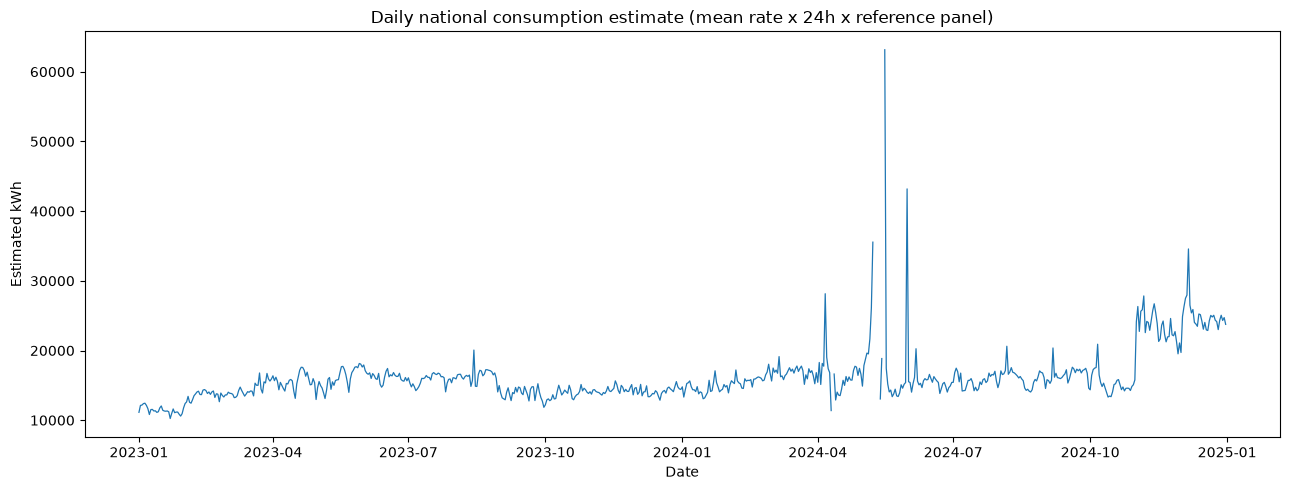

Top 5 spike days:
date
2024-05-16    63150.499048
2024-05-31    43188.360210
2024-05-08    35545.741349
2024-12-06    34573.037140
2024-04-06    28146.693030
Name: rate_kwh_per_hour, dtype: float64

Mean before Nov 2024: 16190.7
Mean Nov-Dec 2024: 24168.3
Std before Nov 2024: 3756.6
Std Nov-Dec 2024: 2258.6


In [49]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_national_v2.index, daily_national_v2.values, linewidth=0.9)
ax.set_title("Daily national consumption estimate (mean rate x 24h x reference panel)")
ax.set_xlabel("Date")
ax.set_ylabel("Estimated kWh")
plt.tight_layout()
plt.show()

print("Top 5 spike days:")
print(daily_national_v2.sort_values(ascending=False).head(5))

pre_nov = daily_national_v2.loc["2024-01-01":"2024-10-31"]
post_nov = daily_national_v2.loc["2024-11-01":"2024-12-31"]
print(f"\nMean before Nov 2024: {pre_nov.mean():.1f}")
print(f"Mean Nov-Dec 2024: {post_nov.mean():.1f}")
print(f"Std before Nov 2024: {pre_nov.std():.1f}")
print(f"Std Nov-Dec 2024: {post_nov.std():.1f}")


This approach also confirmed previously what we found, The data after October 2024 is so incomplete that any "national electricity consumption" estimate becomes unreliable. Therefore we must either discard that period or replace much of it with estimated values, and discarding it is usually the more scientifically trustworthy choice. So we decided to discard it.

**Plot daily distinct household count across the whole series**

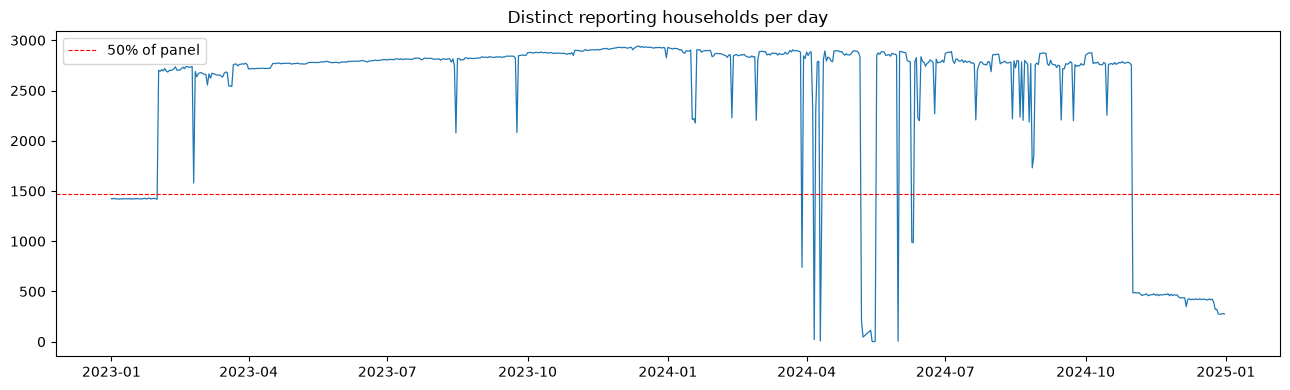

First date below 50% panel coverage: 2023-01-01 00:00:00
Total days below 50% panel coverage: 104


In [50]:
households_per_day = clean.groupby("date")["household_ID"].nunique()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(households_per_day.index, households_per_day.values, linewidth=0.9)
ax.axhline(REFERENCE_PANEL_SIZE * 0.5, color="red", linestyle="--", linewidth=0.8, label="50% of panel")
ax.set_title("Distinct reporting households per day")
ax.legend()
plt.tight_layout()
plt.show()

# Find the first date where household count drops below half the panel and stays there
low_panel_days = households_per_day[households_per_day < REFERENCE_PANEL_SIZE * 0.5]
print("First date below 50% panel coverage:", low_panel_days.index.min())
print("Total days below 50% panel coverage:", len(low_panel_days))

In [52]:
# See how the low-panel days are distributed over time
low_panel_days.index.to_period("M").value_counts().sort_index()

date
2023-01    31
2024-03     1
2024-04     2
2024-05     7
2024-06     2
2024-11    30
2024-12    31
Freq: M, Name: count, dtype: int64

In [53]:
# Find when the panel stabilizes in early 2023
feb_households = households_per_day.loc["2023-02-01":"2023-02-15"]
feb_households

date
2023-02-01    2701
2023-02-02    2691
2023-02-03    2708
2023-02-04    2695
2023-02-05    2719
2023-02-06    2692
2023-02-07    2684
2023-02-08    2700
2023-02-09    2700
2023-02-10    2704
2023-02-11    2716
2023-02-12    2736
2023-02-13    2702
2023-02-14    2704
2023-02-15    2703
Name: household_ID, dtype: int64

**Truncate to the reliable window and finalize the series**

In [54]:
FINAL_START = "2023-02-01"
FINAL_END = "2024-10-31"

daily_final = daily_national_v2.loc[FINAL_START:FINAL_END].copy()
print("Shape:", daily_final.shape)
print("Remaining NaN days:", daily_final.isna().sum())
daily_final[daily_final.isna()]

Shape: (639,)
Remaining NaN days: 6


date
2024-04-11   NaN
2024-05-09   NaN
2024-05-10   NaN
2024-05-11   NaN
2024-05-12   NaN
2024-05-15   NaN
Name: rate_kwh_per_hour, dtype: float64

**null out the remaining low-panel days, then interpolate everything at once""

In [55]:
low_panel_in_window = low_panel_days.index.intersection(daily_final.index)
print(f"Low-panel days still in window: {len(low_panel_in_window)}")
print(low_panel_in_window)

daily_final.loc[low_panel_in_window] = np.nan
print("\nTotal NaN before interpolation:", daily_final.isna().sum())

daily_final = daily_final.interpolate(method="time")
print("Remaining NaN after interpolation:", daily_final.isna().sum())
daily_final.describe()

Low-panel days still in window: 12
DatetimeIndex(['2024-03-29', '2024-04-06', '2024-04-10', '2024-05-07',
               '2024-05-08', '2024-05-13', '2024-05-14', '2024-05-15',
               '2024-05-16', '2024-05-31', '2024-06-09', '2024-06-10'],
              dtype='datetime64[ns]', name='date', freq=None)

Total NaN before interpolation: 17
Remaining NaN after interpolation: 0


count      639.000000
mean     15420.978122
std       1532.268765
min      11848.505008
25%      14208.396147
50%      15369.595619
75%      16434.434526
max      21662.529238
Name: rate_kwh_per_hour, dtype: float64

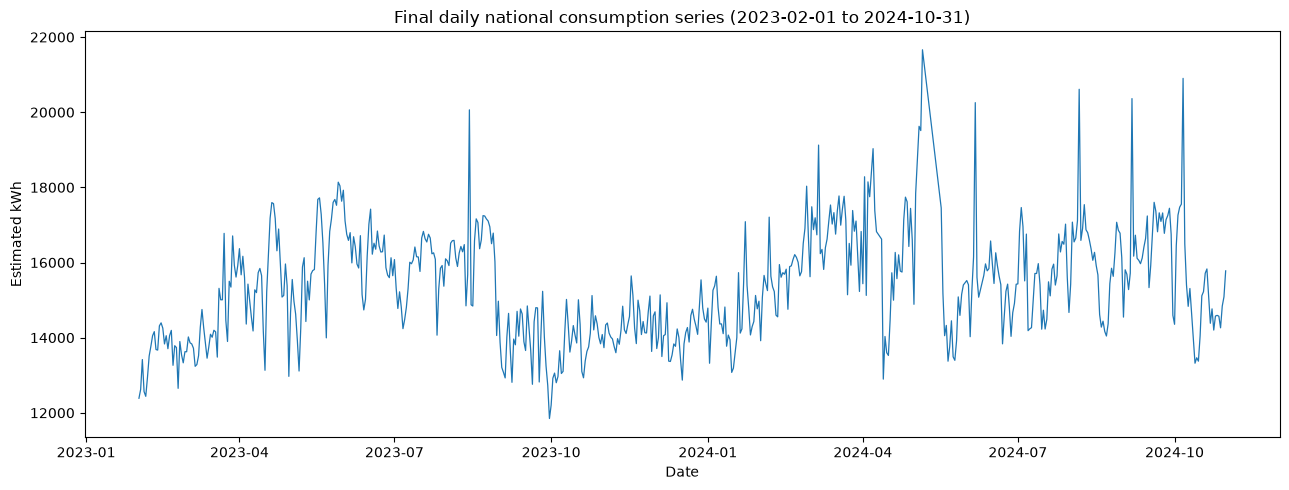

In [56]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_final.index, daily_final.values, linewidth=0.9)
ax.set_title("Final daily national consumption series (2023-02-01 to 2024-10-31)")
ax.set_xlabel("Date")
ax.set_ylabel("Estimated kWh")
plt.tight_layout()
plt.show()

In [57]:
remaining_spikes = daily_final.sort_values(ascending=False).head(10)
print(remaining_spikes)

print("\nHousehold coverage on those days:")
households_per_day.reindex(remaining_spikes.index)

date
2024-05-06    21662.529238
2024-05-07    21279.748584
2024-10-06    20901.127869
2024-05-08    20896.967930
2024-08-06    20611.019598
2024-05-09    20514.187276
2024-09-06    20363.119963
2024-06-06    20255.290576
2024-05-10    20131.406623
2023-08-14    20063.764510
Name: rate_kwh_per_hour, dtype: float64

Household coverage on those days:


date
2024-05-06    2836.0
2024-05-07     209.0
2024-10-06    2767.0
2024-05-08      46.0
2024-08-06    2766.0
2024-05-09       NaN
2024-09-06    2765.0
2024-06-06    2797.0
2024-05-10       NaN
2023-08-14    2746.0
Name: household_ID, dtype: float64

In [59]:
# Inspect the individual readings behind one clean example, 2024-08-06
day6_rows = clean[clean["date"] == "2024-08-06"]
print("Row count:", len(day6_rows))
print(day6_rows["rate_kwh_per_hour"].describe())

# Look at the highest-rate contributors specifically
day6_rows.nlargest(10, "rate_kwh_per_hour")[["household_ID", "timestamp", "elapsed_hours", "interval_kwh", "rate_kwh_per_hour"]]

Row count: 2979
count    2732.000000
mean        0.291610
std         0.378563
min         0.000000
25%         0.086083
50%         0.177755
75%         0.315568
max         2.708539
Name: rate_kwh_per_hour, dtype: float64


,household_ID,timestamp,elapsed_hours,interval_kwh,rate_kwh_per_hour
3290295,ID4827,2024-08-06 01:10:53,5.943056,16.0970,2.708539
2415687,ID4247,2024-08-06 01:09:45,6.036389,16.3370,2.706419
1308240,ID2584,2024-08-06 01:10:28,6.422222,17.3000,2.693772
4104078,ID5365,2024-08-06 01:10:28,5.947500,15.8640,2.667339
3852304,ID5203,2024-08-06 01:08:46,6.274444,16.4900,2.628121
4057896,ID5336,2024-08-06 01:09:54,6.418889,15.7840,2.458993
3990917,ID5292,2024-08-06 01:03:36,5.736111,14.0661,2.452201
4303980,ID5495,2024-08-06 01:08:35,6.308056,15.0900,2.392179
4255808,ID5463,2024-08-06 01:11:01,5.888056,14.0310,2.382960
2224104,ID4096,2024-08-06 01:11:45,5.882500,13.5239,2.299006


**Seasonal decomposition**

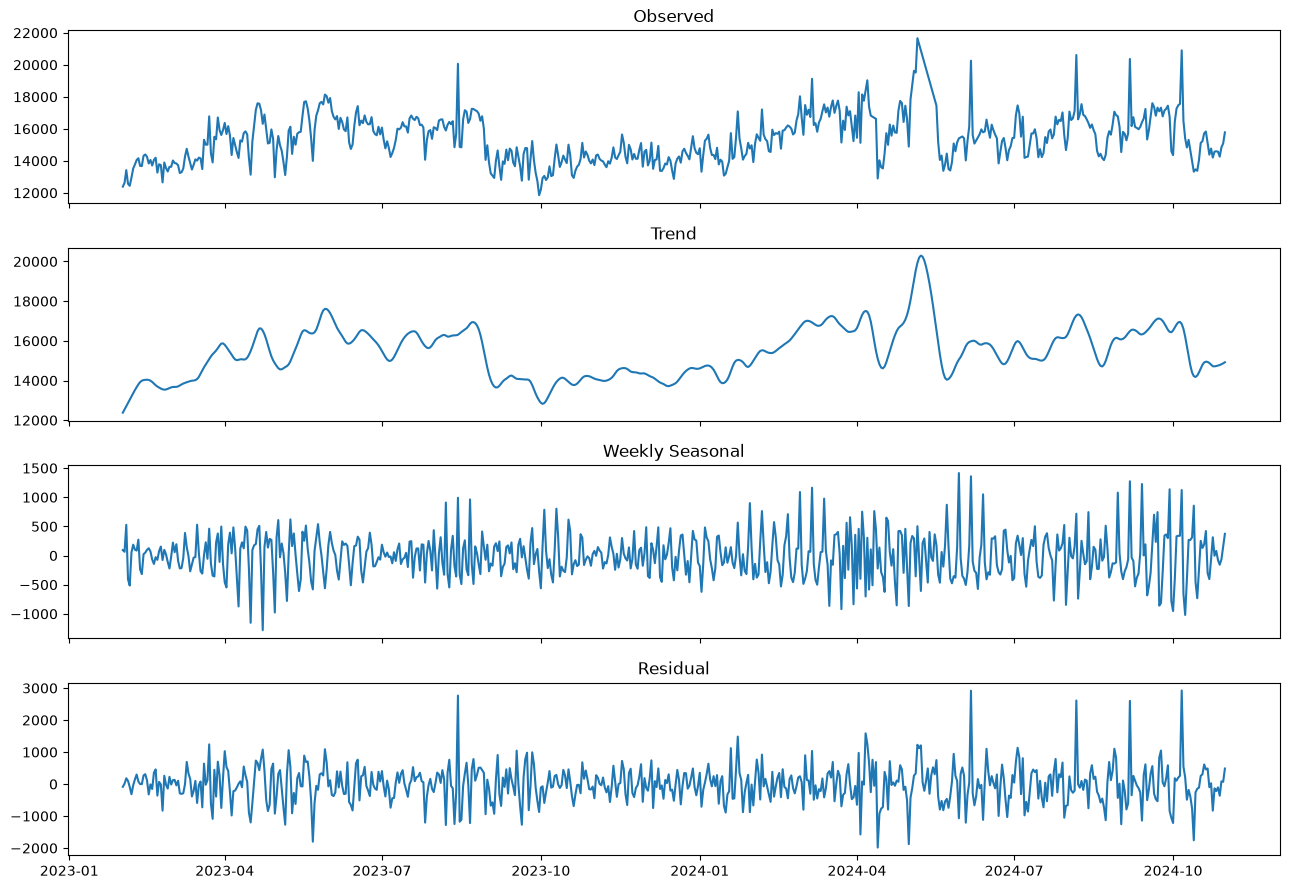

In [60]:
from statsmodels.tsa.seasonal import STL

stl = STL(daily_final, period=7)  # weekly seasonality
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
axes[0].plot(daily_final.index, daily_final.values)
axes[0].set_title("Observed")
axes[1].plot(daily_final.index, result.trend)
axes[1].set_title("Trend")
axes[2].plot(daily_final.index, result.seasonal)
axes[2].set_title("Weekly Seasonal")
axes[3].plot(daily_final.index, result.resid)
axes[3].set_title("Residual")
plt.tight_layout()
plt.show()

**ADF and KPSS tests, on the level series and first difference**

In [61]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_report(series, label):
    adf_stat, adf_p, *_ = adfuller(series.dropna())
    kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"--- {label} ---")
    print(f"ADF:  statistic={adf_stat:.4f}, p-value={adf_p:.4f}  ({'stationary' if adf_p < 0.05 else 'non-stationary'})")
    print(f"KPSS: statistic={kpss_stat:.4f}, p-value={kpss_p:.4f}  ({'non-stationary' if kpss_p < 0.05 else 'stationary'})")
    print()

stationarity_report(daily_final, "Level series")
stationarity_report(daily_final.diff(), "First difference")


--- Level series ---
ADF:  statistic=-5.2686, p-value=0.0000  (stationary)
KPSS: statistic=0.6081, p-value=0.0219  (non-stationary)

--- First difference ---
ADF:  statistic=-8.4445, p-value=0.0000  (stationary)
KPSS: statistic=0.0301, p-value=0.1000  (stationary)



C:\Users\Jana\AppData\Local\Temp\ipykernel_42676\2586937480.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")


**Build lag and rolling-window features**

In [62]:
features = daily_final.to_frame(name="consumption_kwh")

for lag in [1, 7, 14, 30]:
    features[f"lag_{lag}"] = features["consumption_kwh"].shift(lag)

features["rolling_mean_7"] = features["consumption_kwh"].shift(1).rolling(7).mean()
features["rolling_std_7"] = features["consumption_kwh"].shift(1).rolling(7).std()
features["rolling_mean_30"] = features["consumption_kwh"].shift(1).rolling(30).mean()

features["day_of_week"] = features.index.dayofweek
features["is_weekend"] = features["day_of_week"].isin([5, 6]).astype(int)
features["month"] = features.index.month

print(features.shape)
features.head(35)


(639, 11)


,consumption_kwh,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_30,day_of_week,is_weekend,month
date,,,,,,,,,,,
2023-02-01,12387.477138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,2
2023-02-02,12622.352323,12387.477138,NaN,NaN,NaN,NaN,NaN,NaN,3,0,2
2023-02-03,13417.629521,12622.352323,NaN,NaN,NaN,NaN,NaN,NaN,4,0,2
2023-02-04,12566.277166,13417.629521,NaN,NaN,NaN,NaN,NaN,NaN,5,1,2
2023-02-05,12438.794908,12566.277166,NaN,NaN,NaN,NaN,NaN,NaN,6,1,2
2023-02-06,12942.632551,12438.794908,NaN,NaN,NaN,NaN,NaN,NaN,0,0,2
2023-02-07,13513.033081,12942.632551,NaN,NaN,NaN,NaN,NaN,NaN,1,0,2
2023-02-08,13769.698073,13513.033081,12387.477138,NaN,NaN,12841.170955,462.815730,NaN,2,0,2
2023-02-09,14051.437726,13769.698073,12622.352323,NaN,NaN,13038.631089,527.348936,NaN,3,0,2


**Public holiday and tariff-event features**

In [68]:
import holidays

sl_holidays = holidays.country_holidays('LK', years=[2023, 2024])
holiday_dates = pd.to_datetime(list(sl_holidays.keys()))
features["is_sl_public_holiday"] = (features.index.isin(holiday_dates).astype(int))

TARIFF_REVISION_DATES = pd.to_datetime([
    "2023-02-15",  # +66% increase
    "2023-07-01",  # 2nd revision (lower-band reductions)
    "2023-10-20",  # 3rd revision
    "2024-03-04",  # ~21.9% reduction
    "2024-07-16",  # further reduction
])

features["is_tariff_revision_day"] = features.index.isin(TARIFF_REVISION_DATES).astype(int)
features["days_since_tariff_revision"] = features.index.to_series().apply(
    lambda d: min(((d - t).days for t in TARIFF_REVISION_DATES if t <= d), default=-1)
)

print("Public holidays flagged:", features["is_sl_public_holiday"].sum())
print("Tariff revision days flagged:", features["is_tariff_revision_day"].sum())
features[["is_sl_public_holiday", "is_tariff_revision_day", "days_since_tariff_revision"]].describe()

Public holidays flagged: 48
Tariff revision days flagged: 5


,is_sl_public_holiday,is_tariff_revision_day,days_since_tariff_revision
count,639.000000,639.000000,639.000000
mean,0.075117,0.007825,61.251956
std,0.263787,0.088180,37.933212
min,0.000000,0.000000,-1.000000
25%,0.000000,0.000000,29.000000
50%,0.000000,0.000000,61.000000
75%,0.000000,0.000000,92.500000
max,1.000000,1.000000,135.000000


In [71]:
# spot-check the tariff feature around the first revision date
features.loc["2023-02-10":"2023-02-18", ["is_tariff_revision_day", "days_since_tariff_revision"]]

,is_tariff_revision_day,days_since_tariff_revision
date,,
2023-02-10,0,-1
2023-02-11,0,-1
2023-02-12,0,-1
2023-02-13,0,-1
2023-02-14,0,-1
2023-02-15,1,0
2023-02-16,0,1
2023-02-17,0,2
2023-02-18,0,3


**Chronological split and save**

In [72]:
train = features.loc["2023-02-01":"2024-06-30"]
val = features.loc["2024-07-01":"2024-08-31"]
test = features.loc["2024-09-01":"2024-10-31"]

print(f"Train: {train.shape[0]} rows, {train.index.min()} -> {train.index.max()}")
print(f"Val:   {val.shape[0]} rows, {val.index.min()} -> {val.index.max()}")
print(f"Test:  {test.shape[0]} rows, {test.index.min()} -> {test.index.max()}")
print(f"Total: {train.shape[0] + val.shape[0] + test.shape[0]} (should equal {features.shape[0]})")

features.to_parquet("../outputs/features/daily_consumption_engineered.parquet")
print("\nSaved to outputs/features/daily_consumption_engineered.parquet")


Train: 516 rows, 2023-02-01 00:00:00 -> 2024-06-30 00:00:00
Val:   62 rows, 2024-07-01 00:00:00 -> 2024-08-31 00:00:00
Test:  61 rows, 2024-09-01 00:00:00 -> 2024-10-31 00:00:00
Total: 639 (should equal 639)

Saved to outputs/features/daily_consumption_engineered.parquet
